<a href="https://colab.research.google.com/github/Darshan-12345/Deep-Learning-/blob/main/Assignments/Assignment-06/DL_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Import Liberies

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    Add
)

from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"darshanshete0369","key":"bc233f6d4bfd8390f1c8ad30eb482643"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

- use sugarcane leaf images

In [ ]:
!kaggle datasets download -d sunilgautam/sugarcane-leaf-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/sunilgautam/sugarcane-leaf-disease-dataset
License(s): unknown
100% 160M/160M [00:02<00:00, 67.6MB/s]



In [ ]:
import zipfile
import os

zip_path = "/content/sugarcane-leaf-disease-dataset.zip"

extract_path = "/content/sugarcane_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir(extract_path))

['Yellow', 'Rust', 'Mosaic', 'Healthy', 'RedRot']


In [ ]:
for root, dirs, files in os.walk(extract_path):

    print("ROOT:", root)
    print("FOLDERS:", dirs[:10])
    print("FILES:", len(files))

    if len(files) > 0:
        print("Example files:", files[:3])

    print("-" * 50)

ROOT: /content/sugarcane_dataset
FOLDERS: ['Yellow', 'Rust', 'Mosaic', 'Healthy', 'RedRot']
FILES: 0
--------------------------------------------------
ROOT: /content/sugarcane_dataset/Yellow
FOLDERS: []
FILES: 505
Example files: ['yellow (419).jpeg', 'yellow (6).jpeg', 'yellow (238).jpeg']
--------------------------------------------------
ROOT: /content/sugarcane_dataset/Rust
FOLDERS: []
FILES: 514
Example files: ['rust (274).jpeg', 'rust (284).jpeg', 'rust (139).jpeg']
--------------------------------------------------
ROOT: /content/sugarcane_dataset/Mosaic
FOLDERS: []
FILES: 462
Example files: ['mosaic (305).jpeg', 'mosaic (185).jpeg', 'mosaic (390).jpeg']
--------------------------------------------------
ROOT: /content/sugarcane_dataset/Healthy
FOLDERS: []
FILES: 522
Example files: ['healthy (128).jpeg', 'healthy (326).jpeg', 'healthy (167).jpeg']
--------------------------------------------------
ROOT: /content/sugarcane_dataset/RedRot
FOLDERS: []
FILES: 518
Example files: ['re

In [ ]:
dataset_path = "/content/sugarcane_dataset"

print("Dataset path:", dataset_path)
print("Classes:", os.listdir(dataset_path))

Dataset path: /content/sugarcane_dataset
Classes: ['Yellow', 'Rust', 'Mosaic', 'Healthy', 'RedRot']


In [ ]:
classes = [
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Sugarcane Disease Classes:")
print("---------------------------")

for i, cls in enumerate(classes, 1):
    print(f"{i}. {cls}")

print("\nTotal Classes:", len(classes))

Sugarcane Disease Classes:
---------------------------
1. Yellow
2. Rust
3. Mosaic
4. Healthy
5. RedRot

Total Classes: 5


In [ ]:
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

class_counts = {}

for cls in classes:

    class_path = os.path.join(
        dataset_path,
        cls
    )

    count = sum(
        1
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[cls] = count

print("Image count per class:")
print("----------------------")

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Image count per class:
----------------------
Yellow: 505
Rust: 514
Mosaic: 462
Healthy: 522
RedRot: 518


In [ ]:
data = []

for disease_class in classes:

    class_path = os.path.join(
        dataset_path,
        disease_class
    )

    # Convert class name to readable disease name
    if disease_class == "RedRot":
        disease_name = "red rot"
    else:
        disease_name = disease_class.lower()

    for image_name in os.listdir(class_path):

        if not image_name.lower().endswith(
            image_extensions
        ):
            continue

        image_path = os.path.join(
            class_path,
            image_name
        )

        # Create caption
        if disease_class == "Healthy":

            caption = (
                "startseq a healthy sugarcane leaf endseq"
            )

        else:

            caption = (
                f"startseq a sugarcane leaf "
                f"affected by {disease_name} endseq"
            )

        data.append({
            "image": image_path,
            "disease": disease_class,
            "caption": caption
        })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("\nDataset preview:")

df.head(10)

Total images: 2521

Dataset preview:


,image,disease,caption
0,/content/sugarcane_dataset/Yellow/yellow (419)...,Yellow,startseq a sugarcane leaf affected by yellow e...
1,/content/sugarcane_dataset/Yellow/yellow (6).jpeg,Yellow,startseq a sugarcane leaf affected by yellow e...
2,/content/sugarcane_dataset/Yellow/yellow (238)...,Yellow,startseq a sugarcane leaf affected by yellow e...
3,/content/sugarcane_dataset/Yellow/yellow (499)...,Yellow,startseq a sugarcane leaf affected by yellow e...
4,/content/sugarcane_dataset/Yellow/yellow (110)...,Yellow,startseq a sugarcane leaf affected by yellow e...
5,/content/sugarcane_dataset/Yellow/yellow (217)...,Yellow,startseq a sugarcane leaf affected by yellow e...
6,/content/sugarcane_dataset/Yellow/yellow (297)...,Yellow,startseq a sugarcane leaf affected by yellow e...
7,/content/sugarcane_dataset/Yellow/yellow (7).jpeg,Yellow,startseq a sugarcane leaf affected by yellow e...
8,/content/sugarcane_dataset/Yellow/yellow (295)...,Yellow,startseq a sugarcane leaf affected by yellow e...
9,/content/sugarcane_dataset/Yellow/yellow (457)...,Yellow,startseq a sugarcane leaf affected by yellow e...


In [ ]:
for disease in classes:

    print("\nDisease:", disease)

    print(
        df[df["disease"] == disease]["caption"]
        .iloc[0]
    )


Disease: Yellow
startseq a sugarcane leaf affected by yellow endseq

Disease: Rust
startseq a sugarcane leaf affected by rust endseq

Disease: Mosaic
startseq a sugarcane leaf affected by mosaic endseq

Disease: Healthy
startseq a healthy sugarcane leaf endseq

Disease: RedRot
startseq a sugarcane leaf affected by red rot endseq


In [ ]:
print("Total images:", len(df))

print("\nImages per class:")
print(df["disease"].value_counts())

print("\nSample data:")
display(df.sample(5, random_state=42))

Total images: 2521

Images per class:
disease
Healthy    522
RedRot     518
Rust       514
Yellow     505
Mosaic     462
Name: count, dtype: int64

Sample data:


,image,disease,caption
196,/content/sugarcane_dataset/Yellow/yellow (120)...,Yellow,startseq a sugarcane leaf affected by yellow e...
986,/content/sugarcane_dataset/Rust/rust (479).jpeg,Rust,startseq a sugarcane leaf affected by rust endseq
1090,/content/sugarcane_dataset/Mosaic/mosaic (322)...,Mosaic,startseq a sugarcane leaf affected by mosaic e...
387,/content/sugarcane_dataset/Yellow/yellow (317)...,Yellow,startseq a sugarcane leaf affected by yellow e...
2222,/content/sugarcane_dataset/RedRot/redrot (459)...,RedRot,startseq a sugarcane leaf affected by red rot ...


- sample image

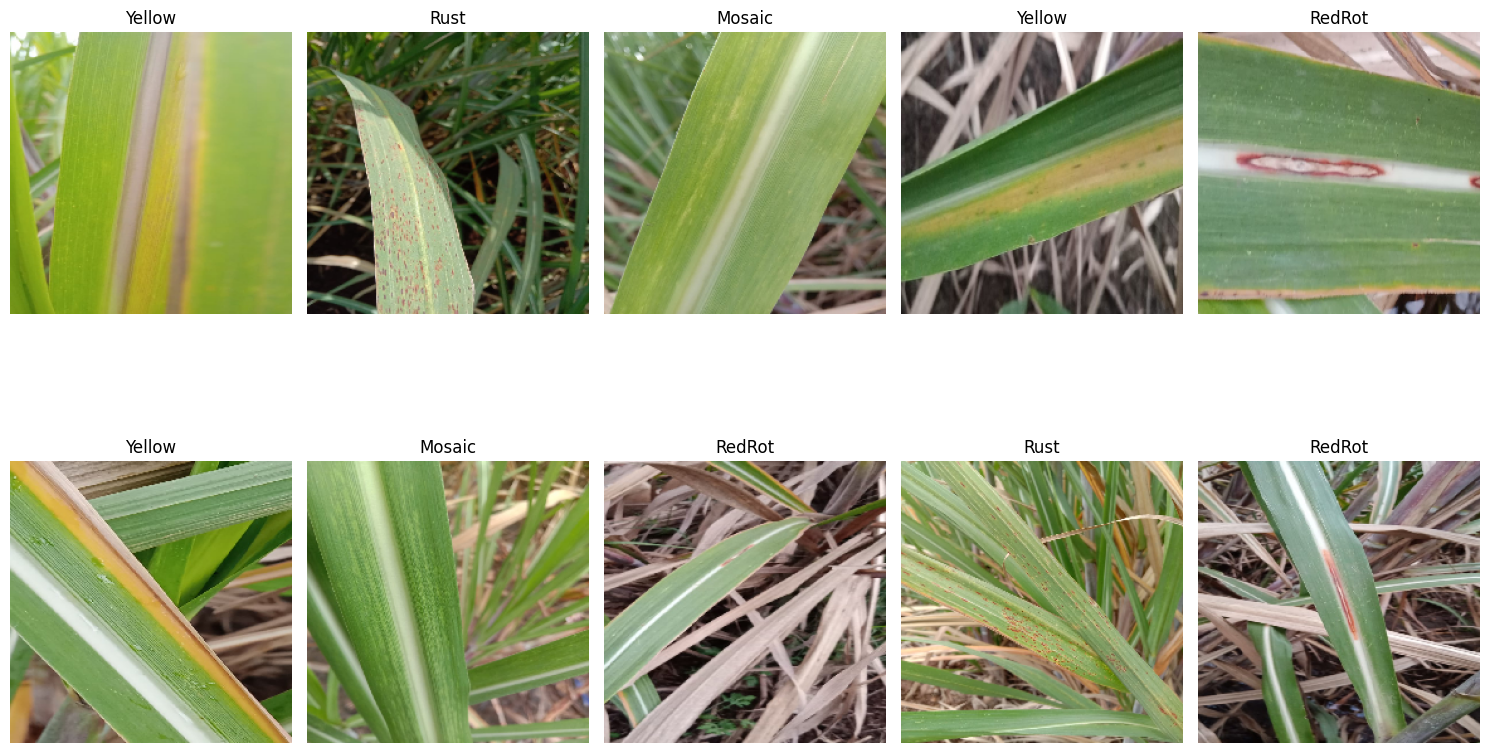

In [ ]:
plt.figure(figsize=(15, 10))

sample_df = df.sample(10, random_state=42)

for i, (_, row) in enumerate(sample_df.iterrows()):

    img = load_img(
        row["image"],
        target_size=(224, 224)
    )

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)

    plt.title(row["disease"])
    plt.axis("off")

plt.tight_layout()
plt.show()

- train/ test split 80-20

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["disease"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Testing images:", len(test_df))

Training images: 2016
Testing images: 505


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=1000,
    oov_token="<unk>"
)

tokenizer.fit_on_texts(
    train_df["caption"]
)

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)

Vocabulary size: 15


In [ ]:
print(tokenizer.word_index)

{'<unk>': 1, 'startseq': 2, 'a': 3, 'sugarcane': 4, 'leaf': 5, 'endseq': 6, 'affected': 7, 'by': 8, 'healthy': 9, 'red': 10, 'rot': 11, 'rust': 12, 'yellow': 13, 'mosaic': 14}


In [ ]:
max_length = max(
    len(caption.split())
    for caption in train_df["caption"]
)

print("Maximum caption length:", max_length)

Maximum caption length: 9


In [ ]:
sample_caption = train_df["caption"].iloc[0]

print("Caption:")
print(sample_caption)

sequence = tokenizer.texts_to_sequences(
    [sample_caption]
)[0]

print("\nToken sequence:")
print(sequence)

Caption:
startseq a sugarcane leaf affected by red rot endseq

Token sequence:
[2, 3, 4, 5, 7, 8, 10, 11, 6]


- load CNN

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model

base_cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

# Freeze CNN
base_cnn.trainable = False

cnn_model = Model(
    inputs=base_cnn.input,
    outputs=base_cnn.output
)

print("CNN output shape:", cnn_model.output_shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN output shape: (None, 1280)


- Extract featuers

In [ ]:
def extract_features(image_paths):

    features = []

    total = len(image_paths)

    for i, path in enumerate(image_paths):

        img = load_img(
            path,
            target_size=(224, 224)
        )

        img = img_to_array(img)

        img = np.expand_dims(
            img,
            axis=0
        )

        img = preprocess_input(img)

        feature = cnn_model.predict(
            img,
            verbose=0
        )

        features.append(feature[0])

        if (i + 1) % 100 == 0:
            print(
                f"Processed {i + 1}/{total} images"
            )

    return np.array(features)

In [ ]:
train_features = extract_features(
    train_df["image"].values
)

print(
    "Training feature shape:",
    train_features.shape
)

Processed 100/2016 images
Processed 200/2016 images
Processed 300/2016 images
Processed 400/2016 images
Processed 500/2016 images
Processed 600/2016 images
Processed 700/2016 images
Processed 800/2016 images
Processed 900/2016 images
Processed 1000/2016 images
Processed 1100/2016 images
Processed 1200/2016 images
Processed 1300/2016 images
Processed 1400/2016 images
Processed 1500/2016 images
Processed 1600/2016 images
Processed 1700/2016 images
Processed 1800/2016 images
Processed 1900/2016 images
Processed 2000/2016 images
Training feature shape: (2016, 1280)


In [ ]:
test_features = extract_features(
    test_df["image"].values
)

print(
    "Testing feature shape:",
    test_features.shape
)

Processed 100/505 images
Processed 200/505 images
Processed 300/505 images
Processed 400/505 images
Processed 500/505 images
Testing feature shape: (505, 1280)


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def create_sequences(df, features, tokenizer, max_length):

    X_image = []
    X_text = []
    y = []

    for idx, caption in enumerate(df["caption"]):

        sequence = tokenizer.texts_to_sequences([caption])[0]

        # Create input-output pairs
        for i in range(1, len(sequence)):

            input_seq = sequence[:i]
            output_word = sequence[i]

            # Pad input sequence
            input_seq = pad_sequences(
                [input_seq],
                maxlen=max_length,
                padding="post"
            )[0]

            X_image.append(features[idx])
            X_text.append(input_seq)
            y.append(output_word)

    return (
        np.array(X_image),
        np.array(X_text),
        np.array(y)
    )

In [ ]:
X_image, X_text, y = create_sequences(
    train_df,
    train_features,
    tokenizer,
    max_length
)

print("Image input shape:", X_image.shape)
print("Text input shape:", X_text.shape)
print("Target shape:", y.shape)

Image input shape: (13692, 1280)
Text input shape: (13692, 9)
Target shape: (13692,)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    Add
)

# =====================================
# CNN FEATURE INPUT
# =====================================

image_input = Input(
    shape=(1280,),
    name="image_features"
)

image_features = Dense(
    256,
    activation="relu"
)(image_input)

image_features = Dropout(0.3)(
    image_features
)


# =====================================
# CAPTION / TEXT INPUT
# =====================================

text_input = Input(
    shape=(max_length,),
    name="caption_input"
)

text_features = Embedding(
    input_dim=vocab_size,
    output_dim=256,
    mask_zero=True
)(text_input)

text_features = LSTM(
    256,
    name="lstm"
)(text_features)


# =====================================
# COMBINE CNN + LSTM
# =====================================

combined = Add()([
    image_features,
    text_features
])


# =====================================
# DENSE LAYER
# =====================================

combined = Dense(
    256,
    activation="relu"
)(combined)

combined = Dropout(0.3)(
    combined
)


# =====================================
# OUTPUT
# =====================================

output = Dense(
    vocab_size,
    activation="softmax",
    name="word_prediction"
)(combined)


# =====================================
# FINAL MODEL
# =====================================

model = Model(
    inputs=[
        image_input,
        text_input
    ],
    outputs=output
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 9, 256)    │      3,840 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 9)         │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout[0][0],    │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_prediction     │ (None, 15)        │      3,855 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 926,735 (3.54 MB)

 Trainable params: 926,735 (3.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

- train the model

In [ ]:
history = model.fit(
    [X_image, X_text],
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.7822 - loss: 0.6544 - val_accuracy: 0.9507 - val_loss: 0.1309
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.9523 - loss: 0.1232 - val_accuracy: 0.9617 - val_loss: 0.0939
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9689 - loss: 0.0830 - val_accuracy: 0.9631 - val_loss: 0.0972
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9713 - loss: 0.0737 - val_accuracy: 0.9690 - val_loss: 0.0813
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.9780 - loss: 0.0600 - val_accuracy: 0.9712 - val_loss: 0.0908
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.9812 - loss: 0.0479 - val_accuracy: 0.9723 - val_loss: 0.0753
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.9856 - loss: 0.0377 - val_accuracy: 0.9752 - val_loss: 0.0700
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9872 - loss: 0.0345 - 

In [ ]:
def generate_caption(image_path):

    # Load image
    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert image to array
    img = img_to_array(img)

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Preprocess for MobileNetV2
    img = preprocess_input(img)

    # Extract CNN feature
    feature = cnn_model.predict(
        img,
        verbose=0
    )

    # Start caption
    caption = "startseq"

    for _ in range(max_length):

        # Convert current caption to numbers
        sequence = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        # Pad sequence
        sequence = pad_sequences(
            [sequence],
            maxlen=max_length,
            padding="post"
        )

        # Predict next word
        prediction = model.predict(
            [feature, sequence],
            verbose=0
        )

        # Get word with highest probability
        word_id = np.argmax(
            prediction[0]
        )

        # Convert ID back to word
        word = None

        for w, idx in tokenizer.word_index.items():

            if idx == word_id:
                word = w
                break

        # If no word found
        if word is None:
            break

        # Add word
        caption += " " + word

        # Stop at end token
        if word == "endseq":
            break

    # Remove start/end tokens
    caption = caption.replace(
        "startseq", ""
    ).replace(
        "endseq", ""
    )

    return caption.strip()

In [ ]:
sample = test_df.sample(
    1,
    random_state=42
).iloc[0]

image_path = sample["image"]

actual_disease = sample["disease"]

generated_caption = generate_caption(
    image_path
)

print("Actual Disease:", actual_disease)
print("Generated Caption:", generated_caption)

Actual Disease: Rust
Generated Caption: a sugarcane leaf affected by rust


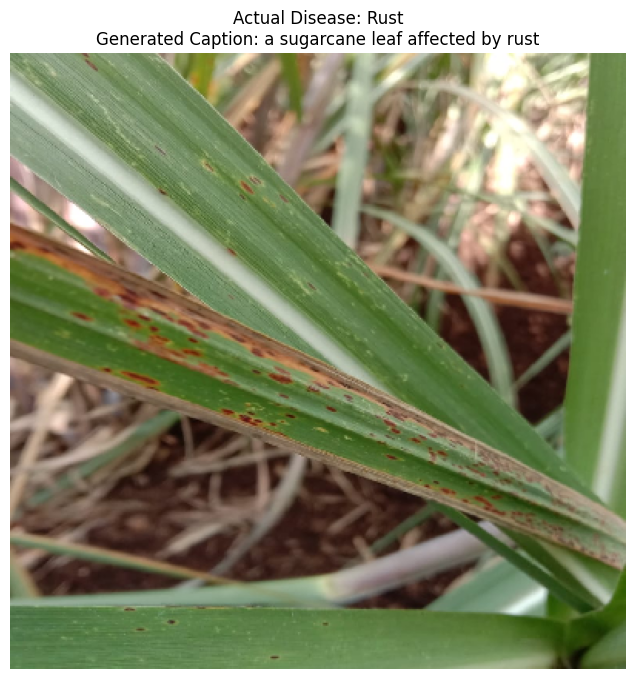

In [ ]:
img = load_img(
    image_path,
    target_size=(400, 400)
)

plt.figure(figsize=(8, 8))

plt.imshow(img)

plt.title(
    f"Actual Disease: {actual_disease}\n"
    f"Generated Caption: {generated_caption}"
)

plt.axis("off")

plt.show()